# Ensemble & Ablation Pipeline — 05_ensemble

This notebook loads the trained XGBoost, BERT and Autoencoder models, runs inference on the test split, and performs a weighted fusion ensemble plus ablation studies and visualisations.

Outputs: ensemble_metrics.json, ablation_results.csv, per_class_f1.csv, ensemble_ablation_plots.png

### Section 1 — Imports & Setup

This cell imports the libraries used across the notebook and defines the base paths for saved artifacts. It reports package versions to help reproducibility.

In [8]:
import sys
print(sys.executable)

c:\Users\yasiru\Desktop\cyber-ai-agent\cyber\Scripts\python.exe


In [10]:
# Section 1: Imports and Setup
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.environ.setdefault('USE_TF', '0')
os.environ.setdefault('USE_FLAX', '0')

import torch
try:
    import tensorflow as tf
except Exception as exc:
    tf = None
    print(f"⚠️ TensorFlow unavailable: {exc}")
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print(f"✅ NumPy      : {np.__version__}")
if tf is not None:
    print(f"✅ TensorFlow : {tf.__version__}")
else:
    print("⚠️ TensorFlow : unavailable")
print(f"✅ PyTorch    : {torch.__version__}")

BASE_DIR     = Path('..')
MODELS_DIR   = BASE_DIR / 'trained_models'
DATASETS_DIR = BASE_DIR / 'datasets'

✅ NumPy      : 2.4.6
✅ TensorFlow : 2.20.0
✅ PyTorch    : 2.12.1+cpu


### Section 2 — Load All Artifacts

Load test data, label maps, and the three trained models. Keep inference artifacts separate so the rest of the notebook focuses on predictions and fusion logic.

In [12]:
# Section 2: Load All Saved Artifacts
print("📂 LOADING ALL ARTIFACTS")
print("=" * 60)

# ── Test data ─────────────────────────────────────────────────────────────────
X_test  = joblib.load(DATASETS_DIR / 'X_test_scaled.pkl').values
y_test  = joblib.load(DATASETS_DIR / 'y_test.pkl').values

# ── Label map ─────────────────────────────────────────────────────────────────
with open(MODELS_DIR / 'reverse_map.json', 'r') as f:
    reverse_map = {int(k): v for k, v in json.load(f).items()}

num_classes  = len(reverse_map)
target_names = [reverse_map[i] for i in sorted(reverse_map.keys())]

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_model = joblib.load(MODELS_DIR / 'xgboost_model.pkl')
print(f"✅ XGBoost model loaded")

# ── BERT ──────────────────────────────────────────────────────────────────────
bert_tokenizer = AutoTokenizer.from_pretrained(str(MODELS_DIR / 'bert_classifier'))
bert_model     = AutoModelForSequenceClassification.from_pretrained(str(MODELS_DIR / 'bert_classifier'))
bert_model.eval()
bert_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(bert_device)
print(f"✅ BERT model loaded on {bert_device}")

# ── Autoencoder ───────────────────────────────────────────────────────────────
if tf is not None:
    ae_model = tf.keras.models.load_model(str(MODELS_DIR / 'autoencoder.keras'))
else:
    from keras.models import load_model
    ae_model = load_model(str(MODELS_DIR / 'autoencoder.keras'))
with open(MODELS_DIR / 'autoencoder_threshold.json', 'r') as f:
    ae_threshold_data = json.load(f)
ae_threshold = float(ae_threshold_data['threshold'])
print(f"✅ Autoencoder loaded | threshold = {ae_threshold:.6f}")

# ── Saved metrics (for cross-check) ──────────────────────────────────────────
with open(MODELS_DIR / 'xgboost_metrics.json',   'r') as f: xgb_saved  = json.load(f)
with open(MODELS_DIR / 'bert_metrics.json',      'r') as f: bert_saved = json.load(f)
with open(MODELS_DIR / 'autoencoder_metrics.json','r') as f: ae_saved   = json.load(f)

print(f"✅ Test set : {X_test.shape[0]:,} samples | {X_test.shape[1]} features")
print(f"✅ Class map  :")
for idx, name in sorted(reverse_map.items()):
    count = (y_test == idx).sum()
    print(f"  {idx} → {name:<15} ({count:,} samples)")

📂 LOADING ALL ARTIFACTS
✅ XGBoost model loaded


Loading weights: 100%|██████████| 41/41 [00:00<00:00, 5856.77it/s]


✅ BERT model loaded on cpu
✅ Autoencoder loaded | threshold = 0.015656
✅ Test set : 241,522 samples | 18 features
✅ Class map  :
  0 → BENIGN          (199,807 samples)
  1 → Bot             (195 samples)
  2 → DDoS            (12,763 samples)
  3 → DoS GoldenEye   (1,028 samples)
  4 → DoS Hulk        (16,694 samples)
  5 → DoS Slowhttptest (518 samples)
  6 → DoS slowloris   (487 samples)
  7 → FTP-Patator     (426 samples)
  8 → Heartbleed      (1 samples)
  9 → Infiltration    (4 samples)
  10 → PortScan        (9,075 samples)
  11 → SSH-Patator     (315 samples)
  12 → Web Attack � Brute Force (142 samples)
  13 → Web Attack � Sql Injection (2 samples)
  14 → Web Attack � XSS (65 samples)


### Section 3 — Get Predictions from Each Model

Run inference for XGBoost, BERT (on generated textual descriptions) and the Autoencoder. Keep each model's raw predictions and confidence scores for fusion.

In [15]:
# Section 3: Generate Predictions from All Models
print("🔮 GENERATING PREDICTIONS")
print("=" * 60)

# ── XGBoost ───────────────────────────────────────────────────────────────────
xgb_raw   = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)
xgb_preds = xgb_raw.astype(int)
xgb_conf  = np.max(xgb_proba, axis=1)
print(f"✅ XGBoost predictions done  — {(xgb_preds != 0).sum()} attacks detected")

# ── BERT ──────────────────────────────────────────────────────────────────────
# Rebuild test texts using the same generate_nlp_description from training
X_test_df = joblib.load(DATASETS_DIR / 'X_test_scaled.pkl')

def generate_nlp_description(row) -> str:
    """Identical to 03_bert.ipynb — single source of truth."""
    duration  = int(max(row.get('Flow Duration', 0), 1))
    fwd_pkts  = int(row.get('Total Fwd Packets', 0))
    bwd_pkts  = int(row.get('Total Backward Packets', 0))
    fwd_bytes = int(row.get('Total Length of Fwd Packets', 0))
    bwd_bytes = int(row.get('Total Length of Bwd Packets', 0))
    flow_bps  = float(row.get('Flow Bytes/s', 0))
    flow_pps  = float(row.get('Flow Packets/s', 0))
    iat_mean  = float(row.get('Flow IAT Mean', 0))
    fwd_iat   = float(row.get('Fwd IAT Mean', 0))
    bwd_iat   = float(row.get('Bwd IAT Mean', 0))
    avg_pkt   = float(row.get('Average Packet Size', 0))
    port      = int(row.get('Destination Port', 0))
    fwd_psh   = int(row.get('Fwd PSH Flags', 0))
    bwd_psh   = int(row.get('Bwd PSH Flags', 0))
    fwd_urg   = int(row.get('Fwd URG Flags', 0))
    bwd_urg   = int(row.get('Bwd URG Flags', 0))

    total_pkts    = fwd_pkts + bwd_pkts
    pkt_ratio     = fwd_pkts / (bwd_pkts + 1)
    payload_label = 'large'    if avg_pkt > 800         else 'small'
    flow_label    = 'balanced' if 0.5 < pkt_ratio < 2.0 else 'skewed'
    pattern_label = ('suspicious burst behavior'
                     if flow_pps > 1000 else 'normal flow characteristics')

    text = (
        f"Network flow analysis detected on destination port {port}. "
        f"Session duration is {duration} ms with {total_pkts} total packets. "
        f"Forward traffic consists of {fwd_pkts} packets ({fwd_bytes} bytes), "
        f"while backward traffic consists of {bwd_pkts} packets ({bwd_bytes} bytes). "
        f"Traffic intensity is {flow_bps:.2f} bytes per second "
        f"with packet rate {flow_pps:.2f} packets per second. "
        f"Packet size averages {avg_pkt:.2f} bytes "
        f"indicating {payload_label} payload behavior. "
        f"Timing analysis shows flow IAT mean of {iat_mean:.2f} ms, "
        f"forward IAT {fwd_iat:.2f} ms, backward IAT {bwd_iat:.2f} ms. "
        f"Packet direction ratio is {pkt_ratio:.2f} "
        f"indicating {flow_label} traffic flow. "
        f"TCP flag behavior shows PSH activity (FWD:{fwd_psh}, BWD:{bwd_psh}) "
        f"and URG activity (FWD:{fwd_urg}, BWD:{bwd_urg}). "
        f"Overall traffic pattern suggests {pattern_label}."
    )
    return ' '.join(text.split())

print("Generating BERT text descriptions...")
test_texts = [generate_nlp_description(row) for _, row in X_test_df.iterrows()]
print(f"✅ {len(test_texts):,} text descriptions generated")

# Batch inference
BATCH_SIZE  = 64
bert_preds_list = []
bert_proba_list = []

print("Running BERT inference...")
for i in range(0, len(test_texts), BATCH_SIZE):
    batch    = test_texts[i : i + BATCH_SIZE]
    encoding = bert_tokenizer(
        batch,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    )
    encoding = {k: v.to(bert_device) for k, v in encoding.items()}
    with torch.no_grad():
        logits = bert_model(**encoding).logits
    proba = torch.softmax(logits, dim=-1).cpu().numpy()
    preds = np.argmax(proba, axis=1)
    bert_preds_list.extend(preds.tolist())
    bert_proba_list.extend(proba.tolist())

bert_preds = np.array(bert_preds_list)
bert_proba = np.array(bert_proba_list)
bert_conf  = np.max(bert_proba, axis=1)
print(f"✅ BERT predictions done      — {(bert_preds != 0).sum()} attacks detected")

# ── Autoencoder ───────────────────────────────────────────────────────────────
print("Running Autoencoder inference...")
ae_reconstructed = ae_model.predict(X_test, verbose=0)
ae_errors        = np.mean((X_test - ae_reconstructed) ** 2, axis=1)
ae_norm_scores   = np.clip(ae_errors / (ae_threshold + 1e-9), 0, 1)
ae_preds_binary  = (ae_errors > ae_threshold).astype(int)   # binary: 0=normal, 1=anomaly
print(f"✅ Autoencoder predictions done — {ae_preds_binary.sum()} anomalies detected")

🔮 GENERATING PREDICTIONS
✅ XGBoost predictions done  — 41294 attacks detected
Generating BERT text descriptions...
✅ 241,522 text descriptions generated
Running BERT inference...
✅ BERT predictions done      — 6220 attacks detected
Running Autoencoder inference...
✅ Autoencoder predictions done — 23773 anomalies detected


### Section 4 — Fusion

Combine signals from the three models using a directional confidence-based fusion. The logic rescales directional signals into [0,1] and applies a fusion threshold to suppress low-confidence alerts.

In [17]:
# Section 4: Weighted Fusion Ensemble
print("⚙️  RUNNING WEIGHTED FUSION")
print("=" * 60)

WEIGHTS = {'xgboost': 0.40, 'bert': 0.35, 'autoencoder': 0.25}
FUSION_THRESHOLD = 0.30

fusion_labels  = np.zeros(len(y_test), dtype=int)
fusion_scores  = np.zeros(len(y_test))

for i in range(len(y_test)):
    xgb_label  = int(xgb_preds[i])
    bert_label = int(bert_preds[i])
    xgb_c      = float(xgb_conf[i])
    bert_c     = float(bert_conf[i])
    ae_anomaly = bool(ae_preds_binary[i])
    ae_norm    = float(ae_norm_scores[i])

    # Directional signals: +conf = attack, -conf = benign
    xgb_signal  = xgb_c  if xgb_label  != 0 else -xgb_c
    bert_signal = bert_c if bert_label != 0 else -bert_c
    ae_signal   = ae_norm if ae_anomaly      else -ae_norm

    raw      = (WEIGHTS['xgboost']     * xgb_signal +
                WEIGHTS['bert']        * bert_signal +
                WEIGHTS['autoencoder'] * ae_signal)
    combined = (raw + 1.0) / 2.0   # rescale [-1,1] → [0,1]

    fusion_scores[i] = combined

    if combined < FUSION_THRESHOLD:
        final_label = 0
    elif xgb_label == bert_label:
        final_label = xgb_label
    elif xgb_label != 0 and bert_label != 0:
        final_label = xgb_label if xgb_c >= bert_c else bert_label
    else:
        final_label = xgb_label if xgb_c >= bert_c else bert_label

    fusion_labels[i] = final_label

print(f"✅ Fusion complete")
print(f"   Threshold : {FUSION_THRESHOLD}")
print(f"   Threats   : {(fusion_labels != 0).sum():,}")
print(f"   Benign    : {(fusion_labels == 0).sum():,}")

⚙️  RUNNING WEIGHTED FUSION
✅ Fusion complete
   Threshold : 0.3
   Threats   : 35,695
   Benign    : 205,827


### Section 5 — Individual Model Evaluation

Compute multiclass and binary metrics for each model and the fusion output, and cross-check them against saved metrics from the individual notebooks.

In [22]:
# Section 5: Evaluate Each Model
print("📊 INDIVIDUAL MODEL EVALUATION")
print("=" * 60)

y_true = y_test.copy()

def evaluate_multiclass(name, y_pred, y_true=y_true):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1 Score': f1}

def evaluate_binary(name, y_pred_binary, y_true_binary):
    acc  = accuracy_score(y_true_binary, y_pred_binary)
    prec = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    rec  = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1   = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1 Score': f1}

y_true_binary = (y_true != 0).astype(int)

# Metrics
xgb_metrics    = evaluate_multiclass('XGBoost Only', xgb_preds)
bert_metrics   = evaluate_multiclass('BERT Only', bert_preds)
fusion_metrics = evaluate_multiclass('Fusion (Ours)', fusion_labels)

ae_metrics = evaluate_binary(
    'Autoencoder (Binary)',
    ae_preds_binary,
    y_true_binary
)

# Print table
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print('-' * 62)

for m in [xgb_metrics, bert_metrics, ae_metrics, fusion_metrics]:
    print(f"{m['Model']:<22} {m['Accuracy']:>9.4f} {m['Precision']:>10.4f} "
          f"{m['Recall']:>8.4f} {m['F1 Score']:>8.4f}")

# Cross-check saved metrics
print("\n📋 Cross-check against saved notebook metrics:")
print(f"  XGBoost saved F1 : {xgb_saved.get('f1_score', 'N/A')}")
print(f"  XGBoost here F1  : {xgb_metrics['F1 Score']:.4f}")

print(f"  BERT saved F1    : {bert_saved.get('test_f1_score', 'N/A')}")
print(f"  BERT here F1     : {bert_metrics['F1 Score']:.4f}")

print(f"  AE saved F1      : {ae_saved.get('f1_score', 'N/A')}")
print(f"  AE here F1       : {ae_metrics['F1 Score']:.4f}")

📊 INDIVIDUAL MODEL EVALUATION
Model                   Accuracy  Precision   Recall       F1
--------------------------------------------------------------
XGBoost Only              0.9969     0.9965   0.9969   0.9964
BERT Only                 0.8018     0.6808   0.8018   0.7364
Autoencoder (Binary)      0.9091     0.9154   0.5217   0.6646
Fusion (Ours)             0.9750     0.9748   0.9750   0.9713

📋 Cross-check against saved notebook metrics:
  XGBoost saved F1 : 0.9969173983513733
  XGBoost here F1  : 0.9964
  BERT saved F1    : N/A
  BERT here F1     : 0.7364
  AE saved F1      : 0.6645797703396042
  AE here F1       : 0.6646


### Section 6 — Ablation Study

Run variants of the fusion where one or more components are removed to quantify each model's contribution to ensemble performance.

In [25]:
# Section 6: Ablation Study
print("📉 ABLATION STUDY")
print("=" * 60)
print("Tests what happens when each component is removed from the ensemble.")

def fusion_without(skip: str, idx: int) -> int:
    """Run fusion for one sample skipping one model."""
    weights = {k: v for k, v in WEIGHTS.items() if k != skip}
    total_w = sum(weights.values())

    xgb_label  = int(xgb_preds[idx])
    bert_label = int(bert_preds[idx])
    xgb_c      = float(xgb_conf[idx])
    bert_c     = float(bert_conf[idx])
    ae_anomaly = bool(ae_preds_binary[idx])
    ae_norm    = float(ae_norm_scores[idx])

    signals = {
        'xgboost':     xgb_c  if xgb_label  != 0 else -xgb_c,
        'bert':        bert_c if bert_label != 0 else -bert_c,
        'autoencoder': ae_norm if ae_anomaly else -ae_norm
    }

    raw      = sum(weights[k] * signals[k] for k in weights) / total_w
    combined = (raw + 1.0) / 2.0

    if combined < FUSION_THRESHOLD:
        return 0
    elif xgb_label == bert_label and skip not in ('xgboost', 'bert'):
        return xgb_label
    elif skip == 'xgboost':
        return bert_label if combined >= FUSION_THRESHOLD else 0
    elif skip == 'bert':
        return xgb_label if combined >= FUSION_THRESHOLD else 0
    else:
        return xgb_label if xgb_c >= bert_c else bert_label


# Run ablations
ablation_configs = [
    ('XGBoost Only',              xgb_preds),
    ('BERT Only',                 bert_preds),
    ('Autoencoder Only (Binary)', (y_true_binary, ae_preds_binary)),
    ('XGBoost + BERT (no AE)',    np.array([fusion_without('autoencoder', i)
                                            for i in range(len(y_true))])),
    ('XGBoost + AE (no BERT)',    np.array([fusion_without('bert', i)
                                            for i in range(len(y_true))])),
    ('BERT + AE (no XGBoost)',    np.array([fusion_without('xgboost', i)
                                            for i in range(len(y_true))])),
    ('Full Fusion (Ours)',        fusion_labels),
]

ablation_rows = []

print(f"{'Configuration':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print('-' * 70)

for name, preds in ablation_configs:
    if isinstance(preds, tuple):
        yt, yp = preds
        m = evaluate_binary(name, yp, yt)
    else:
        m = evaluate_multiclass(name, preds)

    ablation_rows.append(m)
    marker = ' ◄ BEST' if name == 'Full Fusion (Ours)' else ''

    print(f"{m['Model']:<30} {m['Accuracy']:>9.4f} {m['Precision']:>10.4f} "
          f"{m['Recall']:>8.4f} {m['F1 Score']:>8.4f}{marker}")


ablation_df = pd.DataFrame(ablation_rows)

📉 ABLATION STUDY
Tests what happens when each component is removed from the ensemble.
Configuration                   Accuracy  Precision   Recall       F1
----------------------------------------------------------------------
XGBoost Only                      0.9969     0.9965   0.9969   0.9964
BERT Only                         0.8018     0.6808   0.8018   0.7364
Autoencoder Only (Binary)         0.9091     0.9154   0.5217   0.6646
XGBoost + BERT (no AE)            0.9750     0.9748   0.9750   0.9713
XGBoost + AE (no BERT)            0.9969     0.9965   0.9969   0.9964
BERT + AE (no XGBoost)            0.8018     0.6808   0.8018   0.7364
Full Fusion (Ours)                0.9750     0.9748   0.9750   0.9713 ◄ BEST


### Section 7 — Per-Class Analysis

Produce classification reports and compare per-class F1 between individual models and the fusion output. This helps identify classes where the ensemble adds the most value.

In [28]:
# Section 7: Per-Class Analysis
print("🔍 PER-CLASS ANALYSIS (FUSION MODEL)")
print("=" * 60)

print("1. Classification Report — XGBoost:")
print(classification_report(y_true, xgb_preds,
                             target_names=target_names, zero_division=0))

print("2. Classification Report — BERT:")
print(classification_report(y_true, bert_preds,
                             target_names=target_names, zero_division=0))

print("3. Classification Report — Fusion:")
print(classification_report(y_true, fusion_labels,
                             target_names=target_names, zero_division=0))

print("4. Per-class F1 improvement (Fusion vs best individual model):")
print(f"{ 'Class':<15} {'XGBoost F1':>11} {'BERT F1':>9} {'Fusion F1':>10} {'Winner':>10}")
print('-' * 60)

for idx, name in sorted(reverse_map.items()):
    mask    = y_true == idx
    if mask.sum() == 0:
        continue
    xgb_f1    = f1_score(mask.astype(int), (xgb_preds    == idx).astype(int), zero_division=0)
    bert_f1   = f1_score(mask.astype(int), (bert_preds   == idx).astype(int), zero_division=0)
    fusion_f1 = f1_score(mask.astype(int), (fusion_labels == idx).astype(int), zero_division=0)
    best      = max(xgb_f1, bert_f1, fusion_f1)
    winner    = ['XGBoost', 'BERT', 'Fusion'][[xgb_f1, bert_f1, fusion_f1].index(best)]
    print(f"  {name:<13} {xgb_f1:>11.4f} {bert_f1:>9.4f} {fusion_f1:>10.4f} {winner:>10}")

🔍 PER-CLASS ANALYSIS (FUSION MODEL)
1. Classification Report — XGBoost:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    199807
                       Bot       1.00      0.39      0.57       195
                      DDoS       1.00      1.00      1.00     12763
             DoS GoldenEye       0.97      0.87      0.92      1028
                  DoS Hulk       1.00      0.99      1.00     16694
          DoS Slowhttptest       0.99      0.99      0.99       518
             DoS slowloris       1.00      0.98      0.99       487
               FTP-Patator       1.00      1.00      1.00       426
                Heartbleed       0.00      0.00      0.00         1
              Infiltration       1.00      0.25      0.40         4
                  PortScan       0.99      1.00      0.99      9075
               SSH-Patator       0.98      0.98      0.98       315
  Web Attack � Brute Force       0.77      

### Section 8 — Plot

Create visual summaries for the ablation study, metric comparisons and the fusion score distribution. Save the figure for reporting.

📈 GENERATING PLOTS


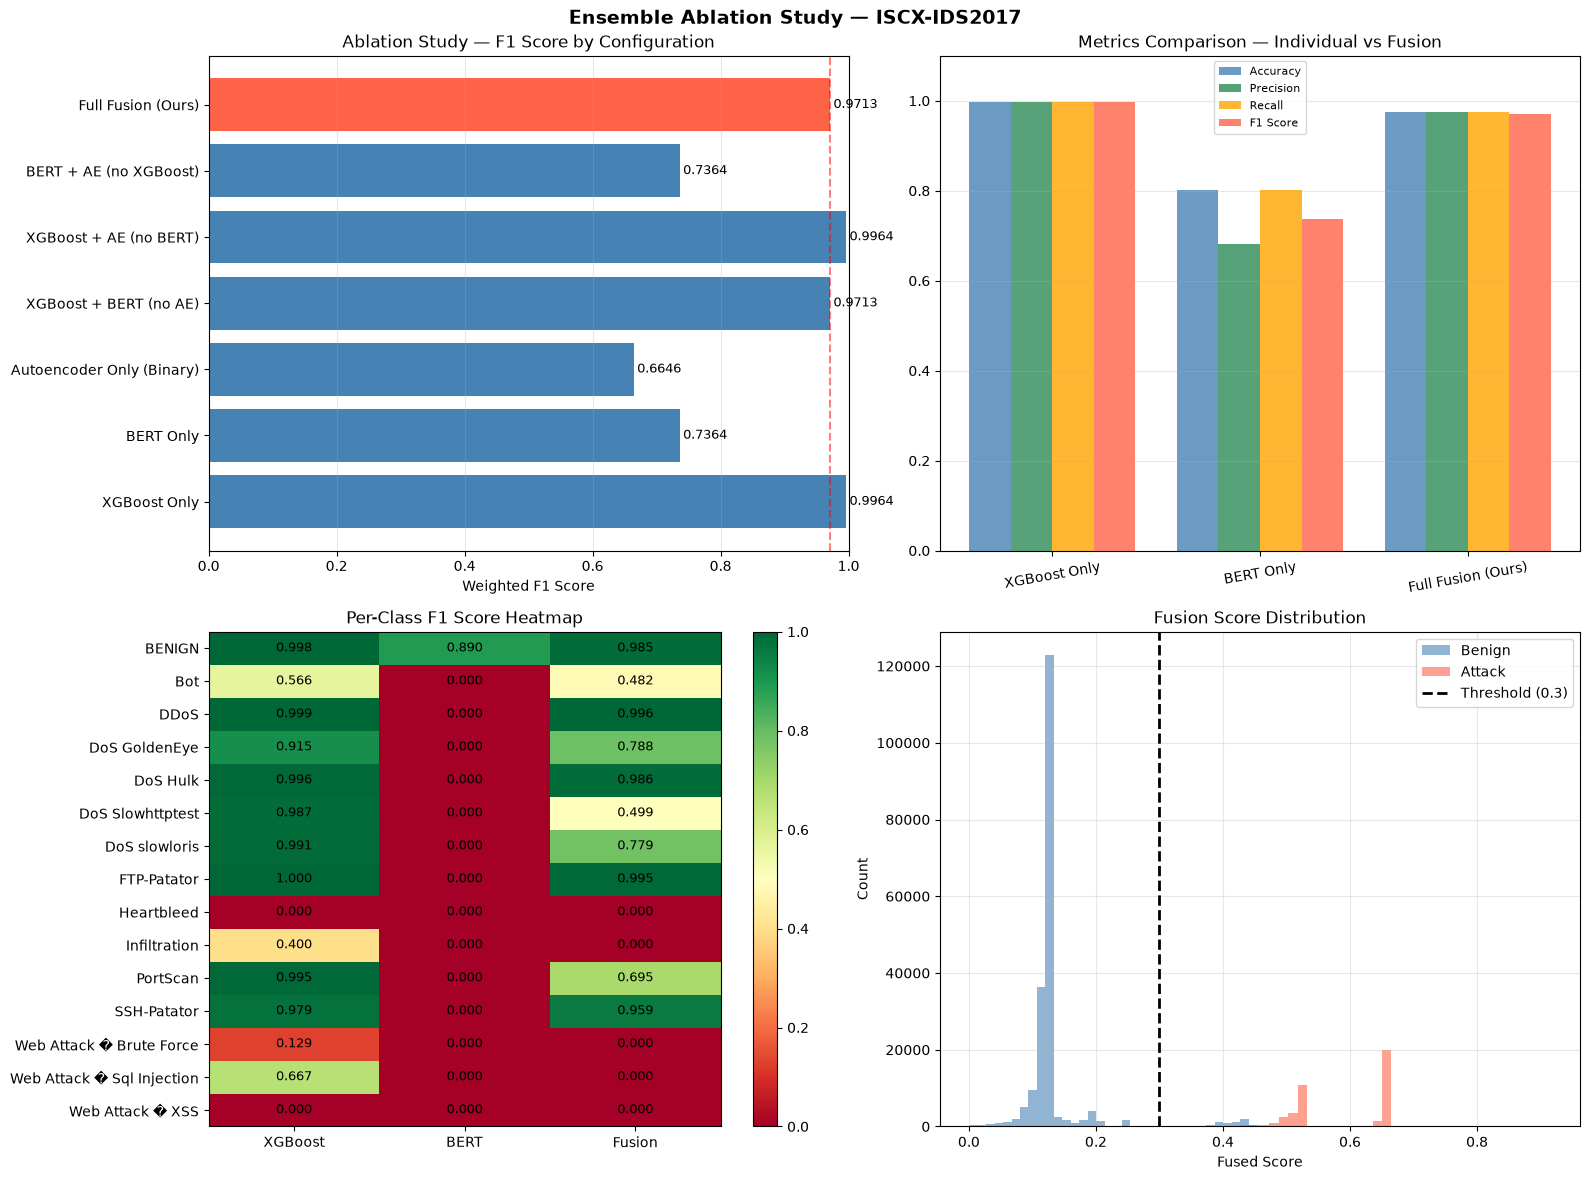

✅ Saved: ensemble_ablation_plots.png


In [30]:
# Section 8: Visualisations
print("📈 GENERATING PLOTS")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── 1. Ablation F1 bar chart ──────────────────────────────────────────────────
models = ablation_df['Model']
f1s    = ablation_df['F1 Score']
colors = ['steelblue'] * (len(models) - 1) + ['tomato']

axes[0, 0].barh(models, f1s, color=colors)
axes[0, 0].set_xlabel('Weighted F1 Score')
axes[0, 0].set_title('Ablation Study — F1 Score by Configuration')
axes[0, 0].axvline(f1s.iloc[-1], color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_xlim(0, 1)
for i, v in enumerate(f1s):
    axes[0, 0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
axes[0, 0].grid(True, alpha=0.3, axis='x')

# ── 2. Accuracy comparison ────────────────────────────────────────────────────
main_models  = ['XGBoost Only', 'BERT Only', 'Full Fusion (Ours)']
main_metrics = ablation_df[ablation_df['Model'].isin(main_models)]
x     = np.arange(len(main_models))
width = 0.2
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
bar_colors      = ['steelblue', 'seagreen', 'orange', 'tomato']

for j, (metric, color) in enumerate(zip(metrics_to_plot, bar_colors)):
    axes[0, 1].bar(x + j * width,
                   main_metrics[metric].values,
                   width, label=metric, color=color, alpha=0.8)

axes[0, 1].set_xticks(x + width * 1.5)
axes[0, 1].set_xticklabels(main_models, rotation=10)
axes[0, 1].set_ylim(0, 1.1)
axes[0, 1].set_title('Metrics Comparison — Individual vs Fusion')
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# ── 3. Per-class F1 heatmap ───────────────────────────────────────────────────
class_f1_data = []
for idx, name in sorted(reverse_map.items()):
    mask = y_true == idx
    if mask.sum() == 0:
        continue
    class_f1_data.append({
        'Class':   name,
        'XGBoost': f1_score(mask.astype(int), (xgb_preds    == idx).astype(int), zero_division=0),
        'BERT':    f1_score(mask.astype(int), (bert_preds   == idx).astype(int), zero_division=0),
        'Fusion':  f1_score(mask.astype(int), (fusion_labels == idx).astype(int), zero_division=0),
    })

class_f1_df  = pd.DataFrame(class_f1_data).set_index('Class')
im = axes[1, 0].imshow(class_f1_df.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[1, 0].set_xticks(range(len(class_f1_df.columns)))
axes[1, 0].set_xticklabels(class_f1_df.columns)
axes[1, 0].set_yticks(range(len(class_f1_df.index)))
axes[1, 0].set_yticklabels(class_f1_df.index)
axes[1, 0].set_title('Per-Class F1 Score Heatmap')
plt.colorbar(im, ax=axes[1, 0])
for r in range(len(class_f1_df.index)):
    for c in range(len(class_f1_df.columns)):
        axes[1, 0].text(c, r, f'{class_f1_df.values[r, c]:.3f}',
                        ha='center', va='center', fontsize=9)

# ── 4. Fusion score distribution ──────────────────────────────────────────────
benign_scores = fusion_scores[y_true == 0]
attack_scores = fusion_scores[y_true != 0]

axes[1, 1].hist(benign_scores, bins=60, alpha=0.6, label='Benign', color='steelblue')
axes[1, 1].hist(attack_scores, bins=60, alpha=0.6, label='Attack', color='tomato')
axes[1, 1].axvline(FUSION_THRESHOLD, color='black', linestyle='--',
                   linewidth=2, label=f'Threshold ({FUSION_THRESHOLD})')
axes[1, 1].set_title('Fusion Score Distribution')
axes[1, 1].set_xlabel('Fused Score')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Ensemble Ablation Study — ISCX-IDS2017', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(MODELS_DIR / 'ensemble_ablation_plots.png'), dpi=150)
plt.show()
print("✅ Saved: ensemble_ablation_plots.png")

### Section 9 — Save Results

Persist ablation and per-class results to disk and write a JSON summary of ensemble metrics for reporting.

In [35]:
# Section 9: Save All Results
print("💾 SAVING ENSEMBLE RESULTS")
print("=" * 60)

# ── Ablation table ────────────────────────────────────────────────────────────
ablation_df.to_csv(str(MODELS_DIR / 'ablation_results.csv'), index=False)
print("✅ ablation_results.csv")

# ── Per-class F1 table ────────────────────────────────────────────────────────
class_f1_df.to_csv(str(MODELS_DIR / 'per_class_f1.csv'))
print("✅ per_class_f1.csv")

# ── Ensemble metrics JSON ─────────────────────────────────────────────────────
ensemble_metrics = {
    'model_type':       'Weighted Ensemble (XGBoost + BERT + Autoencoder)',
    'weights':          WEIGHTS,
    'fusion_threshold': FUSION_THRESHOLD,
    'test_samples':     int(len(y_true)),

    'xgboost_f1':       float(xgb_metrics['F1 Score']),
    'bert_f1':          float(bert_metrics['F1 Score']),
    'autoencoder_f1':   float(ae_metrics['F1 Score']),
    'fusion_f1':        float(fusion_metrics['F1 Score']),

    'xgboost_accuracy':  float(xgb_metrics['Accuracy']),
    'bert_accuracy':     float(bert_metrics['Accuracy']),
    'fusion_accuracy':   float(fusion_metrics['Accuracy']),

    'fusion_precision': float(fusion_metrics['Precision']),
    'fusion_recall':    float(fusion_metrics['Recall']),

    'improvement_over_xgboost': float(
        fusion_metrics['F1 Score'] - xgb_metrics['F1 Score']),
    'improvement_over_bert': float(
        fusion_metrics['F1 Score'] - bert_metrics['F1 Score']),
}

with open(str(MODELS_DIR / 'ensemble_metrics.json'), 'w') as f:
    json.dump(ensemble_metrics, f, indent=2)
print("✅ ensemble_metrics.json")

# ── Final summary ─────────────────────────────────────────────────────────────
print(f"{'='*60}")
print("FINAL SUMMARY")
print(f"{'='*60}")
print(f"{'Model':<22} {'F1':>8}  {'Acc':>8}")
print(f"  {'-'*40}")
for m in [xgb_metrics, bert_metrics, ae_metrics, fusion_metrics]:
    marker = ' ◄' if m['Model'] == 'Fusion (Ours)' else ''
    print(f"  {m['Model']:<22} {m['F1 Score']:>8.4f}  {m['Accuracy']:>8.4f}{marker}")

print(f"Fusion vs XGBoost  : {ensemble_metrics['improvement_over_xgboost']:+.4f} F1")
print(f"  Fusion vs BERT     : {ensemble_metrics['improvement_over_bert']:+.4f} F1")
print(f"✅ Ensemble notebook complete!")
print(f"   All outputs → {MODELS_DIR}/")

💾 SAVING ENSEMBLE RESULTS
✅ ablation_results.csv
✅ per_class_f1.csv
✅ ensemble_metrics.json
FINAL SUMMARY
Model                        F1       Acc
  ----------------------------------------
  XGBoost Only             0.9964    0.9969
  BERT Only                0.7364    0.8018
  Autoencoder (Binary)     0.6646    0.9091
  Fusion (Ours)            0.9713    0.9750 ◄
Fusion vs XGBoost  : -0.0251 F1
  Fusion vs BERT     : +0.2349 F1
✅ Ensemble notebook complete!
   All outputs → ..\trained_models/
